In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import norm
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_obesity = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

# Keep only the original (non-synthetic) data
df = df_obesity.iloc[:498, :]

# Verify the shape
print("Original dataset:", df_obesity.shape)
print("Clean dataset:", df.shape)

Original dataset: (2111, 17)
Clean dataset: (498, 17)


In [3]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          498 non-null    object 
 1   Age                             498 non-null    float64
 2   Height                          498 non-null    float64
 3   Weight                          498 non-null    float64
 4   family_history_with_overweight  498 non-null    object 
 5   FAVC                            498 non-null    object 
 6   FCVC                            498 non-null    float64
 7   NCP                             498 non-null    float64
 8   CAEC                            498 non-null    object 
 9   SMOKE                           498 non-null    object 
 10  CH2O                            498 non-null    float64
 11  SCC                             498 non-null    object 
 12  FAF                             498 

In [5]:
#change datatypes
df['FCVC'] = df['FCVC'].astype(object)
df['NCP'] = df['NCP'].astype(object)
df['CH2O'] = df['CH2O'].astype(object)
df['FAF'] = df['FAF'].astype(object)
df['TUE'] = df['TUE'].astype(object)

#add new variable 'BMI'
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
print(df[['Height', 'Weight', 'BMI']].head())

   Height  Weight        BMI
0    1.62    64.0  24.386526
1    1.52    56.0  24.238227
2    1.80    77.0  23.765432
3    1.80    87.0  26.851852
4    1.78    89.8  28.342381


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          498 non-null    object 
 1   Age                             498 non-null    float64
 2   Height                          498 non-null    float64
 3   Weight                          498 non-null    float64
 4   family_history_with_overweight  498 non-null    object 
 5   FAVC                            498 non-null    object 
 6   FCVC                            498 non-null    object 
 7   NCP                             498 non-null    object 
 8   CAEC                            498 non-null    object 
 9   SMOKE                           498 non-null    object 
 10  CH2O                            498 non-null    object 
 11  SCC                             498 non-null    object 
 12  FAF                             498 

In [7]:
df['BMI'].skew()

np.float64(1.03747585460858)

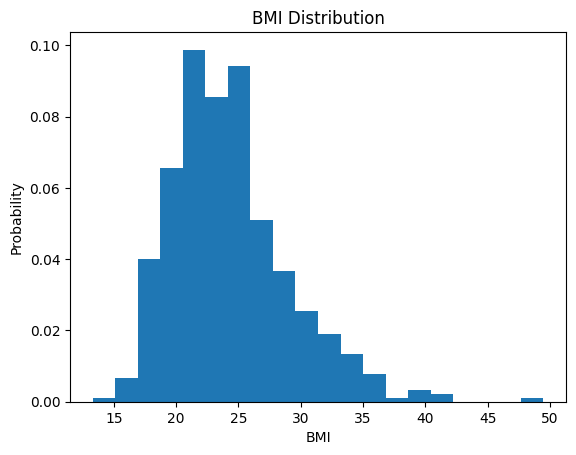

In [8]:
plt.hist(df['BMI'], bins=20, density=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Probability")
plt.show()

In [9]:
from scipy.stats import shapiro

stat, p = shapiro(df['BMI'])
print("Shapiro-Wilk Test statistic:", stat)
print("p-value:", p)


Shapiro-Wilk Test statistic: 0.9465989254980256
p-value: 2.0569244296796905e-12


The BMI distribution is right-skewed, indicating most individuals fall in the normal to overweight range (20–30 BMI), while a smaller proportion have very high BMI values. This skewness reflects an increasing trend toward overweight and obesity within the population.

In [10]:
df.describe(include='all') #includes all columns

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
count,498,498.000000,498.000000,498.000000,498,498,498.0,498.0,498,498,498.0,498,498.0,498.0,498,498,498,498.000000
unique,2,NaN,NaN,NaN,2,2,3.0,3.0,4,2,3.0,2,4.0,3.0,4,5,7,NaN
top,Male,NaN,NaN,NaN,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Normal_Weight,NaN
freq,271,NaN,NaN,NaN,300,348,272.0,344.0,289,466,266.0,443,162.0,243.0,273,326,287,NaN
mean,NaN,23.146586,1.686386,69.569880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.313530
std,NaN,6.721583,0.097653,17.013226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.772267
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.291588
25%,NaN,19.000000,1.612500,58.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.998957
50%,NaN,21.000000,1.680000,67.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.688544
75%,NaN,24.000000,1.750000,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.672763


# DESCRIPTIVE STATS

* 2 unique values, “Male” is the most frequent (271 out of 498).
* Age has a mean of 23.15 years, and Std of 6.72. Most participants are young adults. Range:14-61 years
* **Height** -> mean is 1.68 and std = 0.097 reasonable variation in height.
* **Weight** -> mean is 69.56 and std is 17.013, Range: 39–173 kg → wide variation (includes underweight to obese).
* family_history_with_overweight -> Yes is the most frequently occured value (300) which can suggest a genetic trend.
* **FAVC (Frequent consumption of high-caloric food)**
2 categories-> “Yes” is most occured observation 348/498 which implies majority frequently consume calorie-dense foods. Possible Weight gain risk.(Will be checked in further analysis.)
* **FCVC (Vegetable consumption)** -> Most frequent occurance is “Sometimes” (272) -> Vegetables intake is insufficient in most individuals.
* **NCP (Number of meals per day)** -> Mean = 2.658 -> So most of them eat 2-3 Meals ->Slightly under the normal consumption of the ideal means 3-4.
* **CAEC (Eating between meals)** -> Most common occurane is "Sometimes" (289) -> Unhealthy eating habits(possible).
* **SCC(Calorie Monitoring)** -> The most occurance is 'no' -> 443 which means only about 10% of them track their calorie intake.
* **FAF** -> Majority are in Category 0-1 ( Since mean is 1.16) which implies Low physical activity can be a factor linked to obesity.
* **SMOKE** -> no is the most occurred 466 → 94%
* **CH2O (Water intake)** -> Most common occurance is Between 1 and 2 L (401) -> Hydration is okay
* **Transport (MTRANS)** -> Most common used transport is Public Transportation (326)
* **Target variable: NObeyesdad** -> Most common is Normal_Weight (287)

**SUMMARY**
The descriptive insights show that most participants have low physical activity (FAF), rarely monitor calorie intake (SCC), and often consume high-calorie foods and do not consume vegetables frequqntly.
These trends suggest potential behavioral risk factors for obesity.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          498 non-null    object 
 1   Age                             498 non-null    float64
 2   Height                          498 non-null    float64
 3   Weight                          498 non-null    float64
 4   family_history_with_overweight  498 non-null    object 
 5   FAVC                            498 non-null    object 
 6   FCVC                            498 non-null    object 
 7   NCP                             498 non-null    object 
 8   CAEC                            498 non-null    object 
 9   SMOKE                           498 non-null    object 
 10  CH2O                            498 non-null    object 
 11  SCC                             498 non-null    object 
 12  FAF                             498 

### Demographic factors
* Age
* Gender
* Height
* Weight
* Family History with Overweight


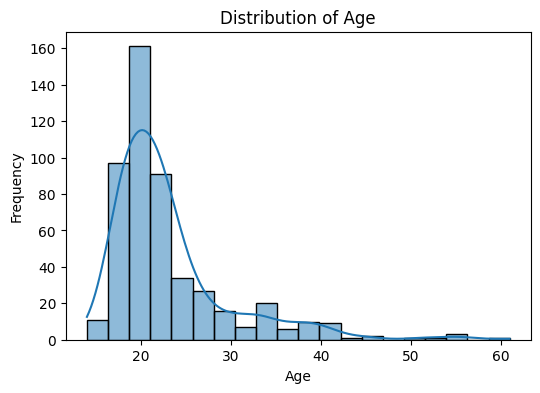

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True, bins=20)
plt.title(f"Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


In [13]:
df['Age'].skew()

np.float64(2.2152865001291646)

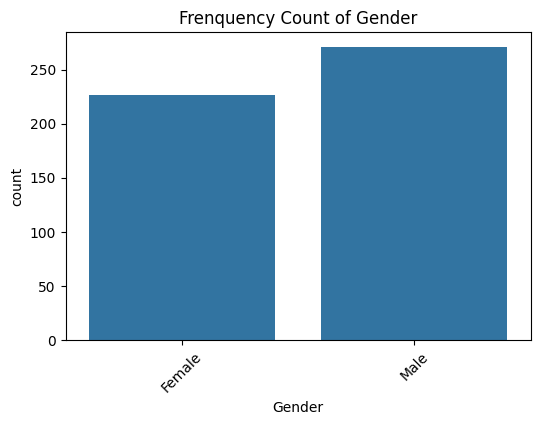

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title(f"Frenquency Count of Gender")
plt.xticks(rotation=45)
plt.show()

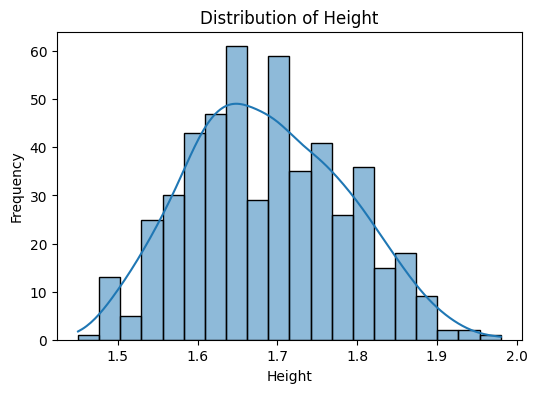

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['Height'], kde=True, bins=20)
plt.title(f"Distribution of Height")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()


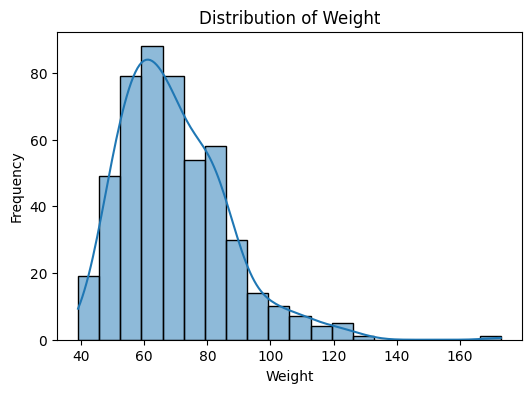

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df['Weight'], kde=True, bins=20)
plt.title(f"Distribution of Weight")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()


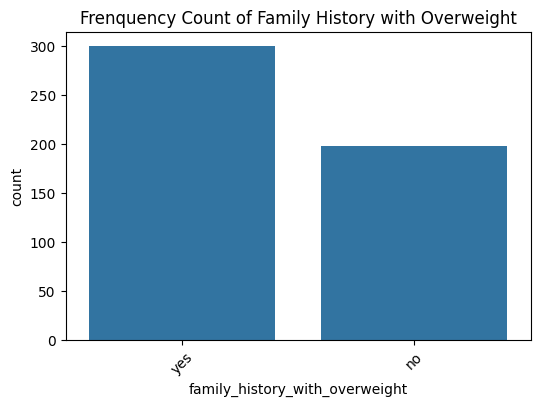

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='family_history_with_overweight', data=df)
plt.title(f"Frenquency Count of Family History with Overweight")
plt.xticks(rotation=45)
plt.show()

### Dietary Factors
* Frequency of Vegetable Consumption
* High-Calorie Food Consumption
* Water Intake
* No. of meals per day
* Calorie Monitoring

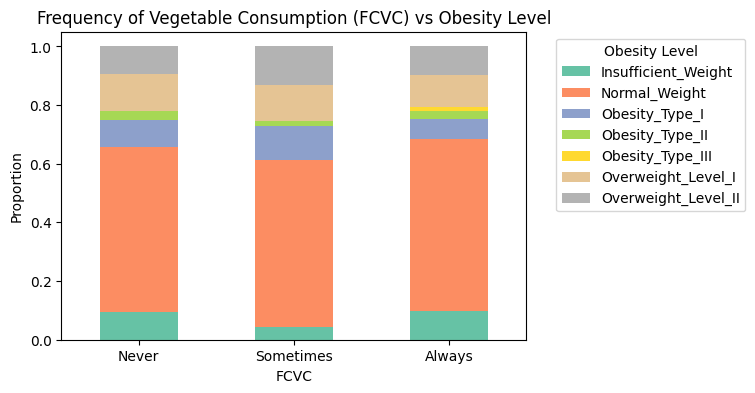

In [18]:
ctab = pd.crosstab(df['FCVC'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("Frequency of Vegetable Consumption (FCVC) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    ticks=range(len(ctab.index)),
    labels=['Never', 'Sometimes', 'Always'],  # put your custom labels here
    rotation=0
)
plt.show()

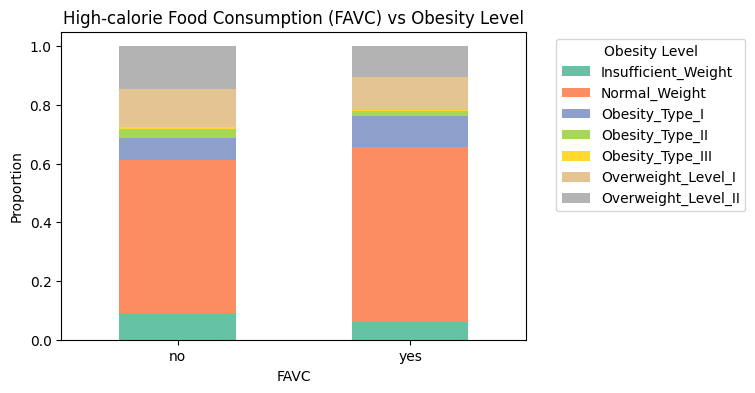

In [19]:
ctab = pd.crosstab(df['FAVC'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("High-calorie Food Consumption (FAVC) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    rotation=0
)
plt.show()

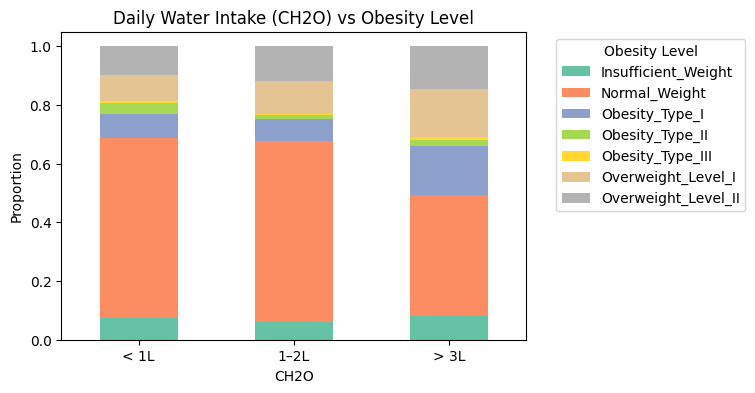

In [20]:
ctab = pd.crosstab(df['CH2O'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("Daily Water Intake (CH2O) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    ticks=range(len(ctab.index)),
    labels=['< 1L', '1–2L', '> 3L'],  # put your custom labels here
    rotation=0
)
plt.show()


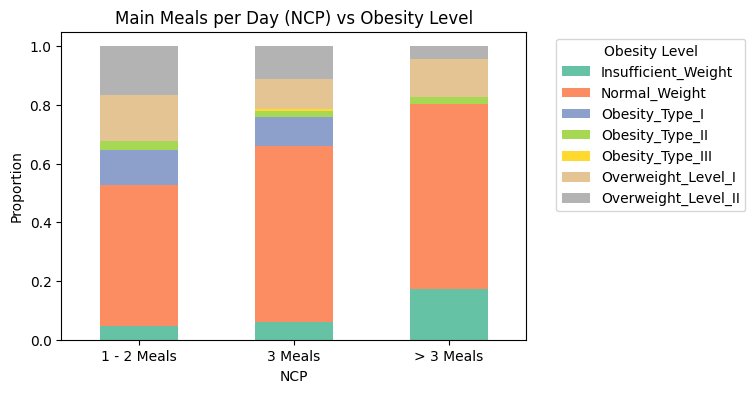

In [21]:
ctab = pd.crosstab(df['NCP'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("Main Meals per Day (NCP) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    ticks=range(len(ctab.index)),
    labels=['1 - 2 Meals', '3 Meals', '> 3 Meals'],  # put your custom labels here
    rotation=0
)
plt.show()

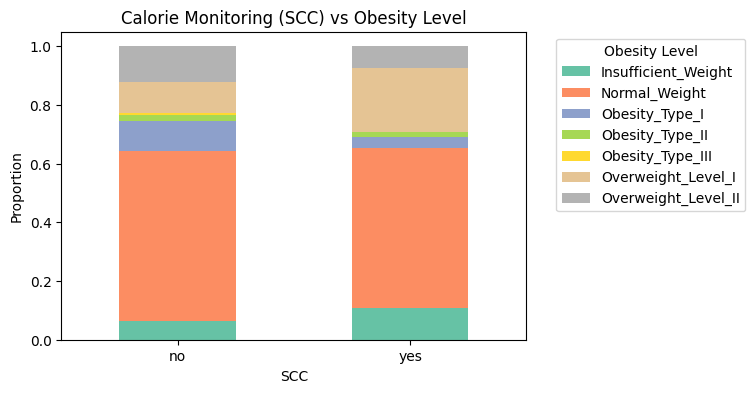

In [22]:
ctab = pd.crosstab(df['SCC'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("Calorie Monitoring (SCC) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    rotation=0
)
plt.show()

### Lifestyle behaviours
* Physical Activity
* Mode of Transportation
* Tech Usage
* Smoking
* Alcohol consumption
* Food Between Meals

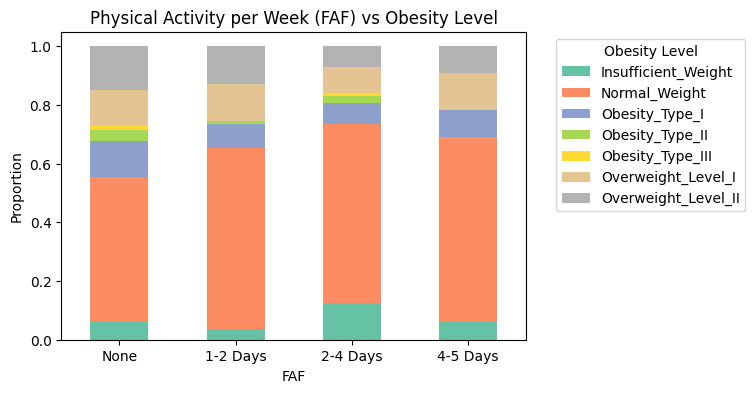

In [23]:
ctab = pd.crosstab(df['FAF'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("Physical Activity per Week (FAF) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    ticks=range(len(ctab.index)),
    labels=['None', '1-2 Days', '2-4 Days', '4-5 Days'],  # put your custom labels here
    rotation=0
)
plt.show()

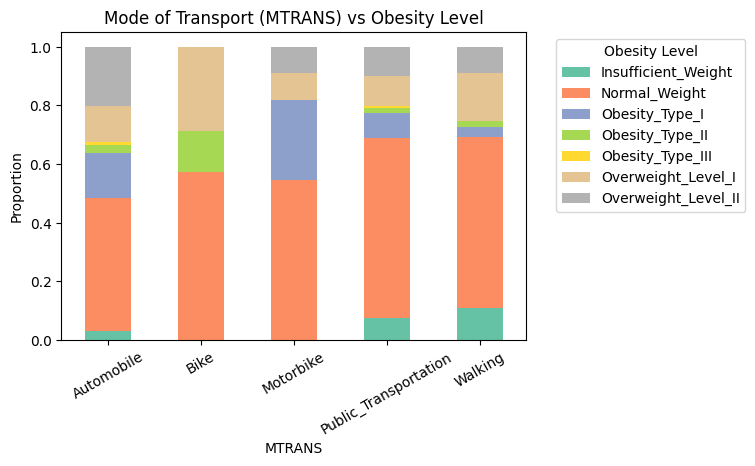

In [24]:
ctab = pd.crosstab(df['MTRANS'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("Mode of Transport (MTRANS) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    rotation=30
)
plt.show()

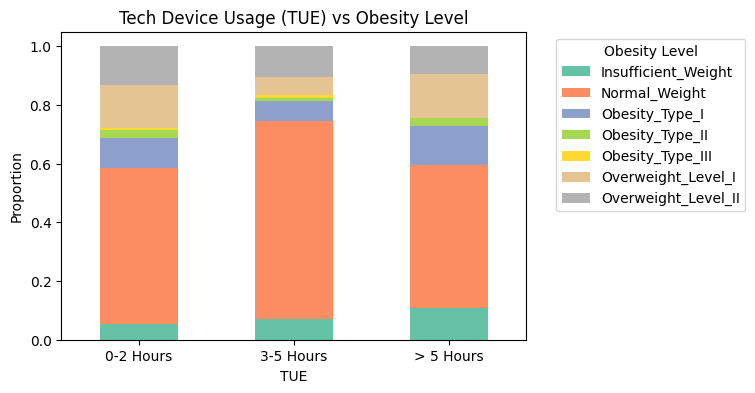

In [25]:
ctab = pd.crosstab(df['TUE'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("Tech Device Usage (TUE) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    ticks=range(len(ctab.index)),
    labels=['0-2 Hours', '3-5 Hours', '> 5 Hours'],  # put your custom labels here
    rotation=0
)
plt.show()

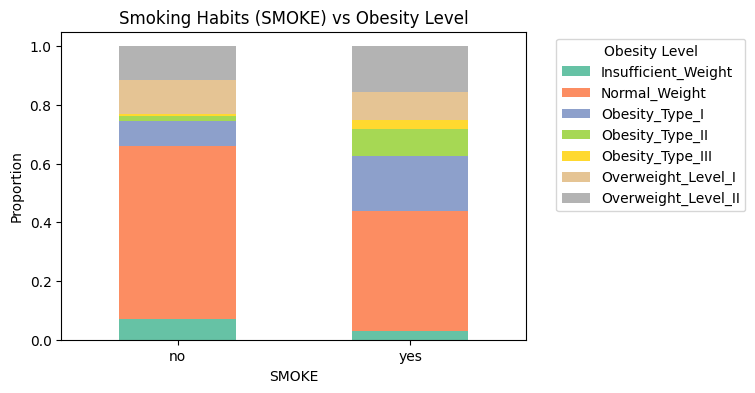

In [26]:
ctab = pd.crosstab(df['SMOKE'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("Smoking Habits (SMOKE) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    # ticks=range(len(ctab.index)),
    # labels=['< 1L', '1–2L', '> 3L'],  # put your custom labels here
    rotation=0
)
plt.show()

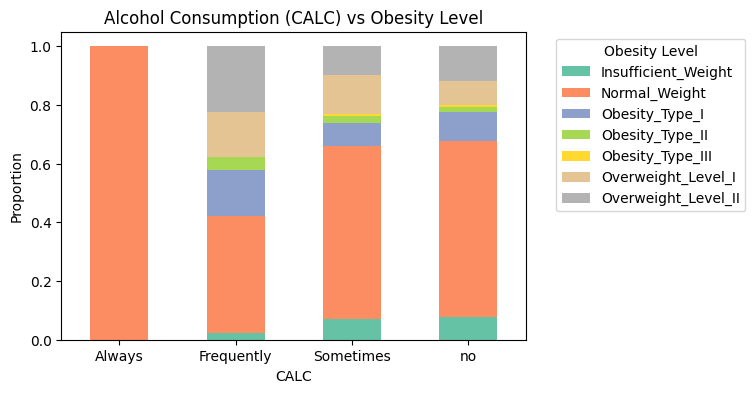

In [27]:
ctab = pd.crosstab(df['CALC'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("Alcohol Consumption (CALC) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    rotation=0
)
plt.show()

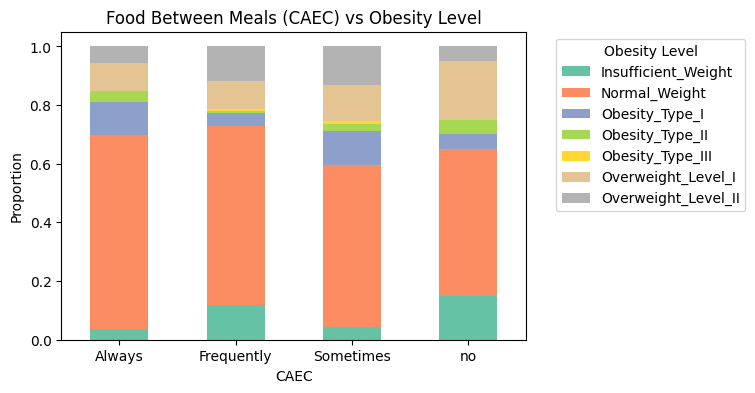

In [28]:
ctab = pd.crosstab(df['CAEC'], df['NObeyesdad'], normalize='index')

ax = ctab.plot(kind='bar', stacked=True, figsize=(6,4), colormap='Set2')
plt.title("Food Between Meals (CAEC) vs Obesity Level")
plt.ylabel("Proportion")
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
# relabel x-axis values
plt.xticks(
    rotation=0
)
plt.show()

### Count Plots

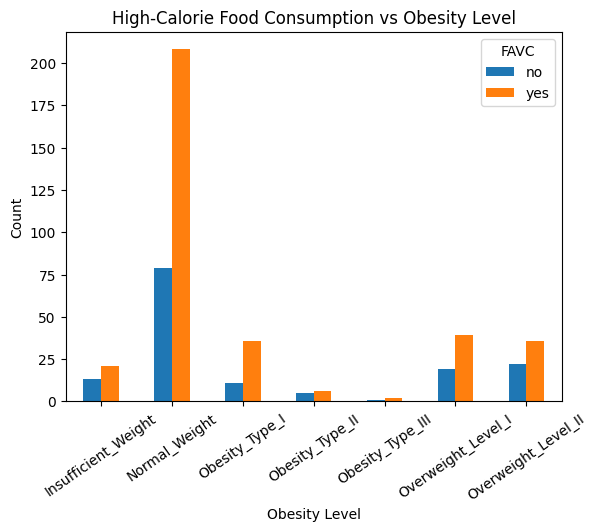

In [29]:
favc_counts = df.groupby('NObeyesdad')['FAVC'].value_counts()
favc_counts.unstack().plot(kind='bar')
plt.title("High-Calorie Food Consumption vs Obesity Level")
plt.xlabel("Obesity Level")
plt.xticks(rotation=35)
plt.ylabel("Count")
plt.show()

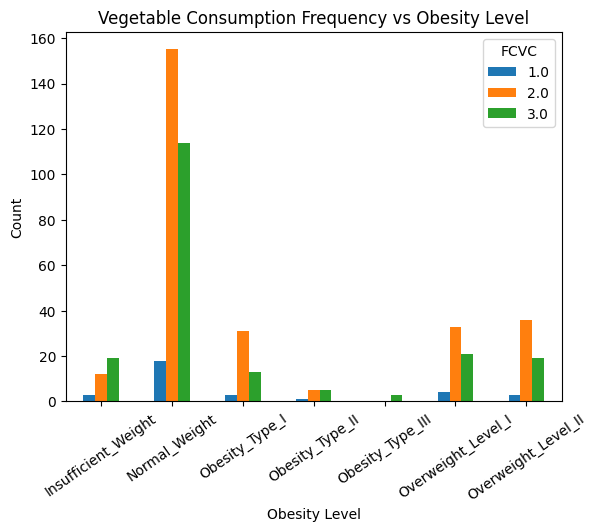

In [30]:
favc_counts = df.groupby('NObeyesdad')['FCVC'].value_counts()
favc_counts.unstack().plot(kind='bar')
plt.title("Vegetable Consumption Frequency vs Obesity Level")
plt.xlabel("Obesity Level")
plt.xticks(rotation=35)
plt.ylabel("Count")
plt.show()

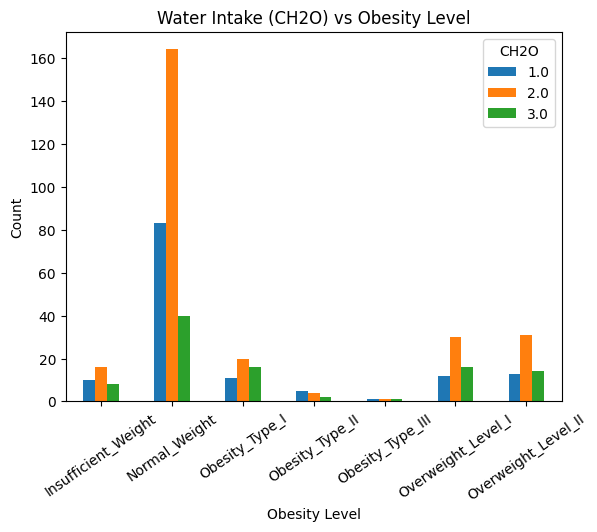

In [31]:
ch2o_counts = df.groupby('NObeyesdad')['CH2O'].value_counts()

ch2o_counts.unstack().plot(kind='bar')
plt.title("Water Intake (CH2O) vs Obesity Level")
plt.xlabel("Obesity Level")
plt.xticks(rotation=35)
plt.ylabel("Count")
plt.show()

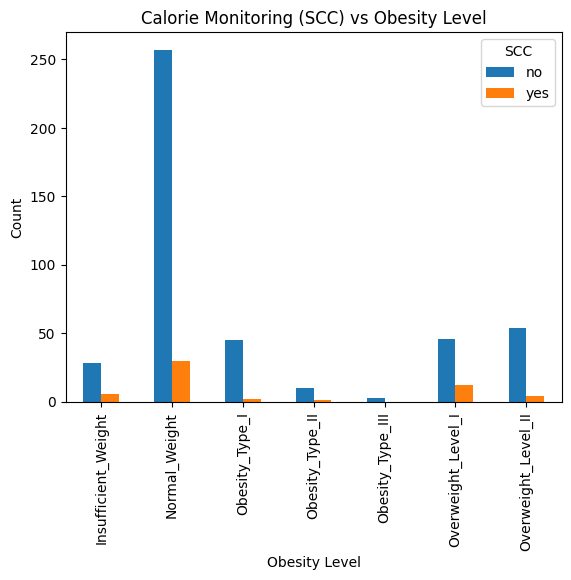

In [32]:
scc_counts = df.groupby('NObeyesdad')['SCC'].value_counts()
scc_counts.unstack().plot(kind='bar')
plt.title("Calorie Monitoring (SCC) vs Obesity Level")
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.show()

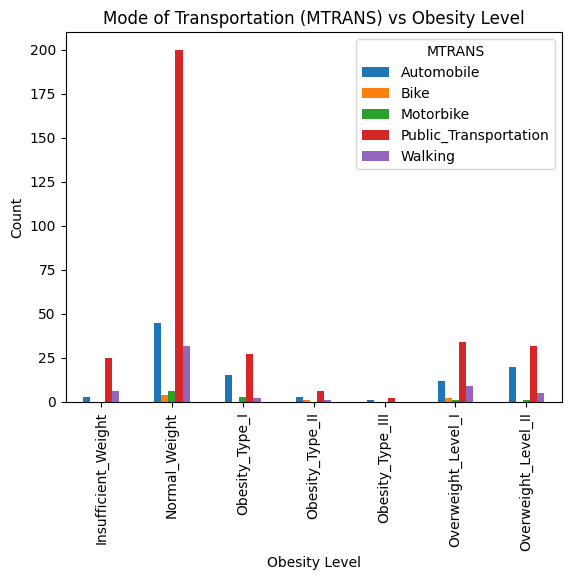

In [33]:
scc_counts = df.groupby('NObeyesdad')['MTRANS'].value_counts()
scc_counts.unstack().plot(kind='bar')
plt.title("Mode of Transportation (MTRANS) vs Obesity Level")
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.show()

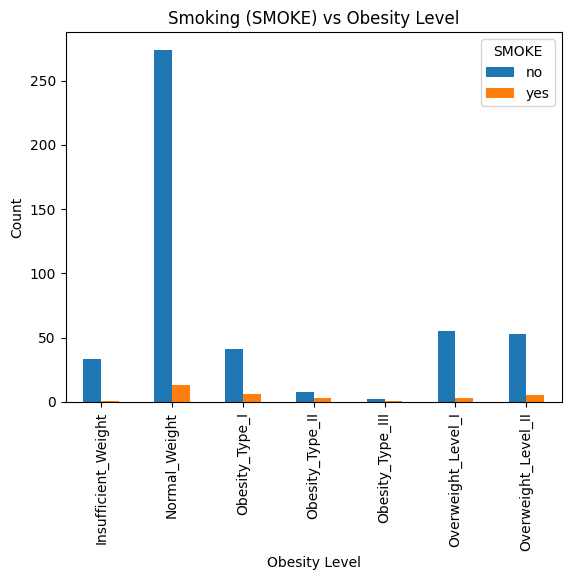

In [34]:
scc_counts = df.groupby('NObeyesdad')['SMOKE'].value_counts()
scc_counts.unstack().plot(kind='bar')
plt.title("Smoking (SMOKE) vs Obesity Level")
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.show()

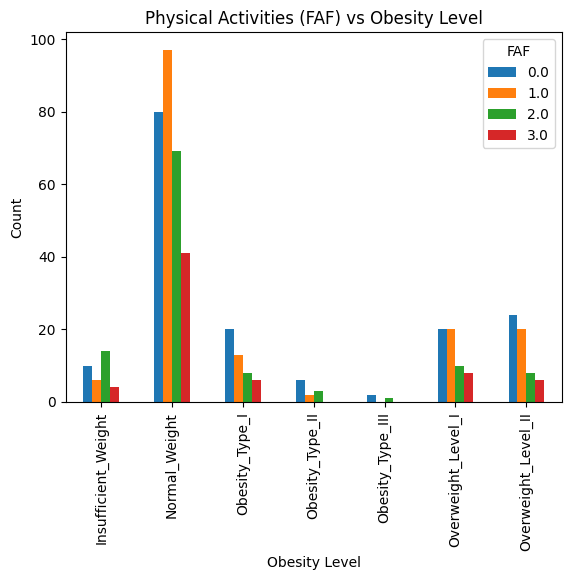

In [35]:
scc_counts = df.groupby('NObeyesdad')['FAF'].value_counts()
scc_counts.unstack().plot(kind='bar')
plt.title("Physical Activities (FAF) vs Obesity Level")
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.show()

# Inferential Stats

In [36]:
df.describe(include='all')

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
count,498,498.000000,498.000000,498.000000,498,498,498.0,498.0,498,498,498.0,498,498.0,498.0,498,498,498,498.000000
unique,2,NaN,NaN,NaN,2,2,3.0,3.0,4,2,3.0,2,4.0,3.0,4,5,7,NaN
top,Male,NaN,NaN,NaN,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Normal_Weight,NaN
freq,271,NaN,NaN,NaN,300,348,272.0,344.0,289,466,266.0,443,162.0,243.0,273,326,287,NaN
mean,NaN,23.146586,1.686386,69.569880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.313530
std,NaN,6.721583,0.097653,17.013226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.772267
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.291588
25%,NaN,19.000000,1.612500,58.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.998957
50%,NaN,21.000000,1.680000,67.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.688544
75%,NaN,24.000000,1.750000,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.672763


# Hypothesis Testing

# Spearman Correlation
**Age vs BMI**

In [37]:
from scipy.stats import spearmanr

rho, p = spearmanr(df['Age'], df['BMI'])
print(f"Spearman correlation (rho): {rho:.3f}, p-value: {p:.4f}")

Spearman correlation (rho): 0.358, p-value: 0.0000


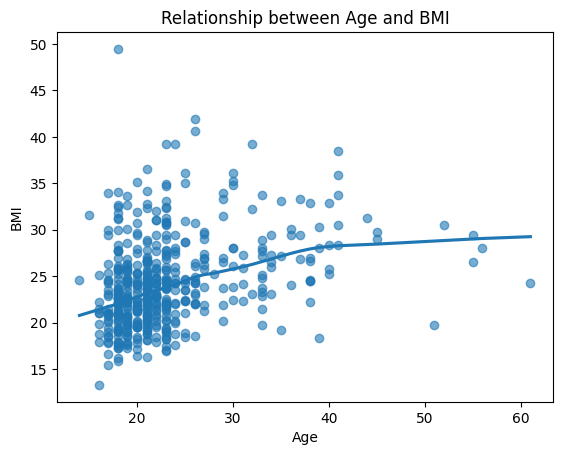

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(x='Age', y='BMI', data=df, scatter_kws={'alpha':0.6}, lowess=True)
plt.title('Relationship between Age and BMI')
plt.show()


There was a weak but statistically significant positive correlation between age and BMI,
indicating that older individuals tended to have slightly higher BMI.

The uneven age distribution limits generalizability of the age–BMI relationship, especially among middle-aged groups.

# Mann-Whitney U Test
Wether distribution of BMI is different across groups for <br>
**SMOKE <br> SCC (Calorie Monitoring) <br> FAVC (High-calorie food consumption) <br> Family History <br> Gender**.

**Is there a significant difference in distribution of BMI between smokers and non-smokers?**

**H0**:There is no difference in the distribution of BMI between smokers and non-smokers.

**H1**:There is difference in the distribution of BMI between smokers and non-smokers.

In [39]:
statistic, p_value = stats.mannwhitneyu(
    df[df['SMOKE']=="yes"]['BMI'],
    df[df['SMOKE']=="no"]['BMI'],
    alternative='two-sided')
print("Mann-Whitney statistic: %.3f and p-value: %.4f" % (statistic, p_value))

Mann-Whitney statistic: 9723.000 and p-value: 0.0040


In [40]:
ranks = stats.rankdata(df['BMI'])
df['rank'] = ranks

group_means = df.groupby('SMOKE')['rank'].mean()
print(group_means)

SMOKE
no     244.635193
yes    320.343750
Name: rank, dtype: float64


p-value (0.004) < 0.05 suggests rejecting H0. There is.

Smokers show a higher average rank than non-smokers, suggesting lower body weight among smoking participants.

Smokers have a higher average rank (≈ higher BMI) than non-smokers.

In [41]:
statistic, p_value = stats.mannwhitneyu(
    df[df['SCC']=="yes"]['BMI'],
    df[df['SCC']=="no"]['BMI'],
    alternative='two-sided')
print("Mann-Whitney statistic: %.3f and p-value: %.4f" % (statistic, p_value))

Mann-Whitney statistic: 11024.000 and p-value: 0.2500


In [42]:
ranks = stats.rankdata(df['BMI'])
df['rank'] = ranks

group_means = df.groupby('SCC')['rank'].mean()
print(group_means)

SCC
no     252.115124
yes    228.436364
Name: rank, dtype: float64


So people who do NOT monitor calories are more overweight on average.

In [43]:
statistic, p_value = stats.mannwhitneyu(
    df[df['FAVC']=="yes"]['BMI'],
    df[df['FAVC']=="no"]['BMI'],
    alternative='two-sided')
print("Mann-Whitney statistic: %.3f and p-value: %.4f" % (statistic, p_value))

Mann-Whitney statistic: 25591.000 and p-value: 0.7300


In [44]:
ranks = stats.rankdata(df['BMI'])
df['rank'] = ranks

group_means = df.groupby('FAVC')['rank'].mean()
print(group_means)

FAVC
no     252.893333
yes    248.037356
Name: rank, dtype: float64


People who do consume high-calorie foods might also be more conscious of their weight.
eating high-calorie foods matters, but in this dataset it’s likely not the strongest factor assosiated with BMI.

In [45]:
statistic, p_value = stats.mannwhitneyu(
    df[df['family_history_with_overweight']=="yes"]['BMI'],
    df[df['family_history_with_overweight']=="no"]['BMI'],
    alternative='two-sided')
print("Mann-Whitney statistic: %.3f and p-value: %.4f" % (statistic, p_value))

Mann-Whitney statistic: 37921.000 and p-value: 0.0000


In [46]:
ranks = stats.rankdata(df['BMI'])
df['rank'] = ranks

group_means = df.groupby('family_history_with_overweight')['rank'].mean()
print(group_means)

family_history_with_overweight
no     207.979798
yes    276.903333
Name: rank, dtype: float64


Individuals with a family history of overweight show higher average rank than those without such a history.

In [47]:
statistic, p_value = stats.mannwhitneyu(
    df[df['Gender']=="Female"]['BMI'],
    df[df['Gender']=="Male"]['BMI'],
    alternative='two-sided')
print("Mann-Whitney statistic: %.3f and p-value: %.4f" % (statistic, p_value))

Mann-Whitney statistic: 25883.500 and p-value: 0.0023


In [48]:
ranks = stats.rankdata(df['BMI'])
df['rank'] = ranks

group_means = df.groupby('Gender')['rank'].mean()
print(group_means)

Gender
Female    228.024229
Male      267.488930
Name: rank, dtype: float64


On average, males have higher ranks → meaning higher BMI values compared to females.

# Kruskal-Wallis
Wether distribution of BMI is different across groups for <br>
**CH2O <br> FCVC <br> NCP <br> FAF <br> MTRANS <br> TUE <br> CALC <br> CAEC**.

**Is there a significant difference in daily water intake (CH2O) between obese and non-obese individuals?**

**H0**:There is no difference in BMI distribution between the CH2O groups

**H1**:There is a significant difference in BMI distribution between at least one pair of CH2O categories

In [49]:
from scipy.stats import kruskal
groups = [df[df['CH2O'] == cat]['BMI'] for cat in df['CH2O'].unique()]
h_stat, p_val = kruskal(*groups)
round(h_stat,4), round(p_val,4)

(np.float64(10.2088), np.float64(0.0061))

In [50]:
!pip install scikit-posthocs

In [51]:
import scikit_posthocs as sp

# Run Dunn's post-hoc test
posthoc_results = sp.posthoc_dunn(
    df,
    val_col='BMI',          # numeric variable
    group_col='CH2O',       # categorical variable
    p_adjust='holm'         # correction for multiple comparisons
)

# Display the pairwise p-values
posthoc_results

,1.0,2.0,3.0
1.0,1.000000,0.280778,0.005339
2.0,0.280778,1.000000,0.021818
3.0,0.005339,0.021818,1.000000


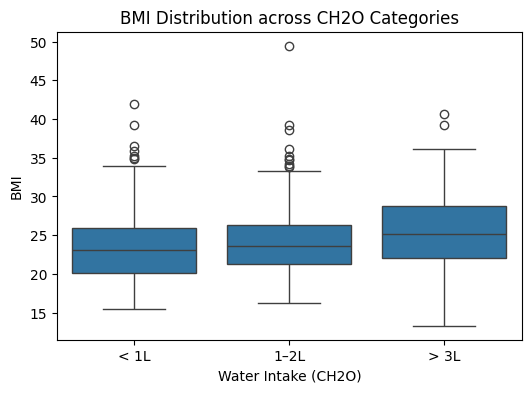

In [52]:
plt.figure(figsize=(6,4))
ax = sns.boxplot(x='CH2O', y='BMI', data=df)
plt.title("BMI Distribution across CH2O Categories")

# Replace numeric CH2O codes with descriptive labels
ax.set_xticklabels(['< 1L', '1–2L', '> 3L'])

plt.xlabel("Water Intake (CH2O)")
plt.ylabel("BMI")
plt.show()


In [53]:
groups = [df[df['FCVC'] == cat]['BMI'] for cat in df['FCVC'].unique()]
h_stat, p_val = kruskal(*groups)
round(h_stat,4), round(p_val,4)

(np.float64(1.2561), np.float64(0.5336))

In [54]:
groups = [df[df['NCP'] == cat]['BMI'] for cat in df['NCP'].unique()]
h_stat, p_val = kruskal(*groups)
round(h_stat,4), round(p_val,4)

(np.float64(19.2923), np.float64(0.0001))

In [55]:
import scikit_posthocs as sp

# Run Dunn's post-hoc test
posthoc_results = sp.posthoc_dunn(
    df,
    val_col='BMI',          # numeric variable
    group_col='NCP',       # categorical variable
    p_adjust='holm'         # correction for multiple comparisons
)

# Display the pairwise p-values
posthoc_results

,1.0,3.0,4.0
1.0,1.000000,0.034690,0.000034
3.0,0.034690,1.000000,0.001155
4.0,0.000034,0.001155,1.000000


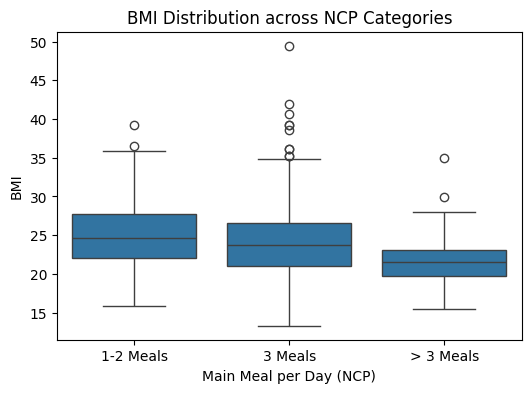

In [56]:
plt.figure(figsize=(6,4))
ax = sns.boxplot(x='NCP', y='BMI', data=df)
plt.title("BMI Distribution across NCP Categories")

# Replace numeric CH2O codes with descriptive labels
ax.set_xticklabels(['1-2 Meals', '3 Meals', '> 3 Meals'])

plt.xlabel("Main Meal per Day (NCP)")
plt.ylabel("BMI")
plt.show()

In [57]:
groups = [df[df['CALC'] == cat]['BMI'] for cat in df['CALC'].unique()]
h_stat, p_val = kruskal(*groups)
round(h_stat,4), round(p_val,4)

(np.float64(15.3901), np.float64(0.0015))

In [58]:
import scikit_posthocs as sp

# Run Dunn's post-hoc test
posthoc_results = sp.posthoc_dunn(
    df,
    val_col='BMI',          # numeric variable
    group_col='CALC',       # categorical variable
    p_adjust='holm'         # correction for multiple comparisons
)

# Display the pairwise p-values
posthoc_results

,Always,Frequently,Sometimes,no
Always,1.0,1.000000,1.000000,1.000000
Frequently,1.0,1.000000,0.001549,0.000767
Sometimes,1.0,0.001549,1.000000,1.000000
no,1.0,0.000767,1.000000,1.000000


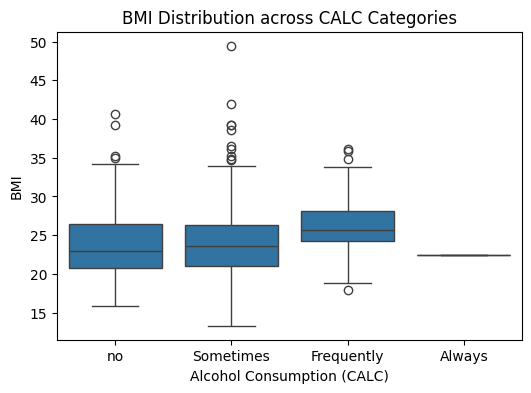

In [59]:
plt.figure(figsize=(6,4))
ax = sns.boxplot(x='CALC', y='BMI', data=df)
plt.title("BMI Distribution across CALC Categories")

plt.xlabel("Alcohol Consumption (CALC)")
plt.ylabel("BMI")
plt.show()

In [60]:
groups = [df[df['FAF'] == cat]['BMI'] for cat in df['FAF'].unique()]
h_stat, p_val = kruskal(*groups)
round(h_stat,4), round(p_val,4)

(np.float64(10.3548), np.float64(0.0158))

In [61]:
import scikit_posthocs as sp

# Run Dunn's post-hoc test
posthoc_results = sp.posthoc_dunn(
    df,
    val_col='BMI',          # numeric variable
    group_col='FAF',       # categorical variable
    p_adjust='holm'         # correction for multiple comparisons
)

# Display the pairwise p-values
posthoc_results

,0.0,1.0,2.0,3.0
0.0,1.000000,0.428550,0.012219,0.275385
1.0,0.428550,1.000000,0.428550,0.981904
2.0,0.012219,0.428550,1.000000,0.981904
3.0,0.275385,0.981904,0.981904,1.000000


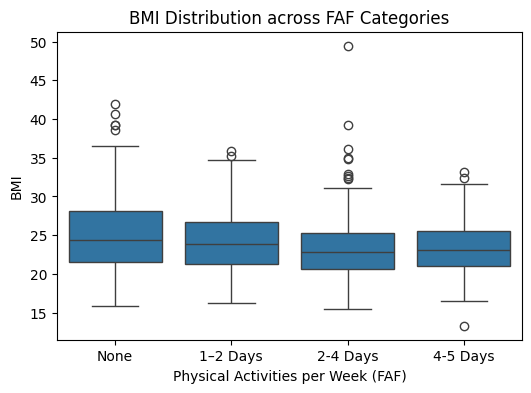

In [62]:
plt.figure(figsize=(6,4))
ax = sns.boxplot(x='FAF', y='BMI', data=df)
plt.title("BMI Distribution across FAF Categories")

# Replace numeric CH2O codes with descriptive labels
ax.set_xticklabels(['None', '1–2 Days', '2-4 Days', '4-5 Days'])

plt.xlabel("Physical Activities per Week (FAF)")
plt.ylabel("BMI")
plt.show()

In [63]:
groups = [df[df['TUE'] == cat]['BMI'] for cat in df['TUE'].unique()]
h_stat, p_val = kruskal(*groups)
round(h_stat,4), round(p_val,4)

(np.float64(8.4208), np.float64(0.0148))

In [64]:
import scikit_posthocs as sp

# Run Dunn's post-hoc test
posthoc_results = sp.posthoc_dunn(
    df,
    val_col='BMI',          # numeric variable
    group_col='TUE',       # categorical variable
    p_adjust='holm'         # correction for multiple comparisons
)

# Display the pairwise p-values
posthoc_results

,0.0,1.0,2.0
0.0,1.000000,0.011188,0.410801
1.0,0.011188,1.000000,0.406547
2.0,0.410801,0.406547,1.000000


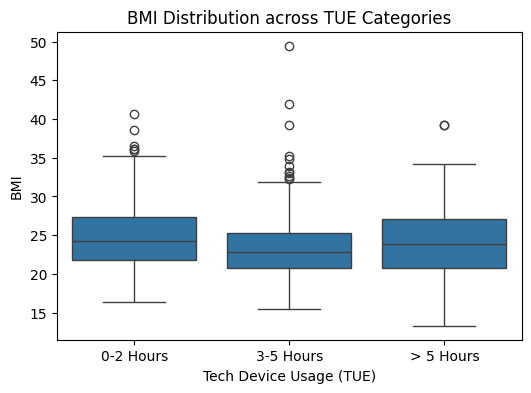

In [65]:
plt.figure(figsize=(6,4))
ax = sns.boxplot(x='TUE', y='BMI', data=df)
plt.title("BMI Distribution across TUE Categories")

# Replace numeric CH2O codes with descriptive labels
ax.set_xticklabels(['0-2 Hours', '3-5 Hours', '> 5 Hours'])

plt.xlabel("Tech Device Usage (TUE)")
plt.ylabel("BMI")
plt.show()

In [66]:
groups = [df[df['MTRANS'] == cat]['BMI'] for cat in df['MTRANS'].unique()]
h_stat, p_val = kruskal(*groups)
round(h_stat,4), round(p_val,4)

(np.float64(19.2652), np.float64(0.0007))

In [67]:
import scikit_posthocs as sp

# Run Dunn's post-hoc test
posthoc_results = sp.posthoc_dunn(
    df,
    val_col='BMI',          # numeric variable
    group_col='MTRANS',       # categorical variable
    p_adjust='holm'         # correction for multiple comparisons
)

# Display the pairwise p-values
posthoc_results

,Automobile,Bike,Motorbike,Public_Transportation,Walking
Automobile,1.000000,1.0,1.0,0.000268,0.064506
Bike,1.000000,1.0,1.0,1.000000,1.000000
Motorbike,1.000000,1.0,1.0,1.000000,1.000000
Public_Transportation,0.000268,1.0,1.0,1.000000,1.000000
Walking,0.064506,1.0,1.0,1.000000,1.000000


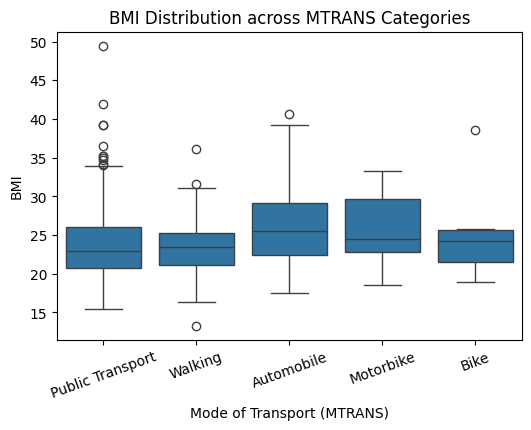

In [68]:
plt.figure(figsize=(6,4))
ax = sns.boxplot(x='MTRANS', y='BMI', data=df)
plt.title("BMI Distribution across MTRANS Categories")

ax.set_xticklabels(['Public Transport', 'Walking', 'Automobile', 'Motorbike', 'Bike'], rotation=20)

plt.xlabel("Mode of Transport (MTRANS)")
plt.ylabel("BMI")
plt.show()

In [69]:
groups = [df[df['CAEC'] == cat]['BMI'] for cat in df['CAEC'].unique()]
h_stat, p_val = kruskal(*groups)
round(h_stat,4), round(p_val,4)

(np.float64(8.4296), np.float64(0.0379))

In [70]:
# Run Dunn's post-hoc test
posthoc_results = sp.posthoc_dunn(
    df,
    val_col='BMI',          # numeric variable
    group_col='CAEC',       # categorical variable
    p_adjust='holm'         # correction for multiple comparisons
)

# Display the pairwise p-values
posthoc_results

,Always,Frequently,Sometimes,no
Always,1.0,1.000000,1.000000,1.0
Frequently,1.0,1.000000,0.025371,1.0
Sometimes,1.0,0.025371,1.000000,1.0
no,1.0,1.000000,1.000000,1.0


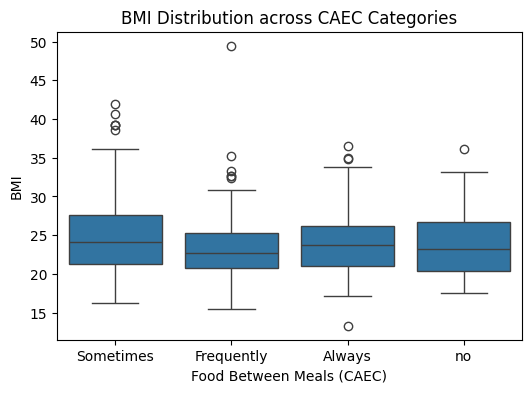

In [71]:
plt.figure(figsize=(6,4))
ax = sns.boxplot(x='CAEC', y='BMI', data=df)
plt.title("BMI Distribution across CAEC Categories")

plt.xlabel("Food Between Meals (CAEC)")
plt.ylabel("BMI")
plt.show()

In [72]:
label_map = {
    'MTRANS': {
        'Automobile': 'Car',
        'Bike': 'Bicycle',
        'Motorbike': 'Motorcycle',
        'Public_Transportation': 'Public Transport',
        'Walking': 'Walking'
    },
    'CH2O': {'1.0': 'Less than 1 L', '2.0': '1–2 L', '3.0': 'More than 2 L'},
    'CALC': {'Never': 'Never', 'Sometimes': 'Sometimes', 'Frequently': 'Frequently', 'Always': 'Always', 'no': 'No'},
    'FAF':  {'0.0': 'None', '1.0': '1–2 days', '2.0': '2–4 days', '3.0': '4–5 days'},
    'TUE':  {'0.0': '0–2 hours', '1.0': '3–5 hours', '2.0': 'More than 5 hours'},
    'CAEC': {'no': 'No', 'Sometimes': 'Sometimes', 'Frequently': 'Frequently', 'Always': 'Always'},
    'FCVC': {'1.0': 'Never', '2.0': 'Sometimes', '3.0': 'Always'},
    'NCP':  {'1.0': '1–2', '3.0': '3', '4.0': 'More than 3'}
}

def dunn_posthoc_matrix(df, group_col, val_col='BMI', p_adjust='holm'):
    """
    Returns a square DataFrame of pairwise p-values (Dunn's test) for val_col across levels of group_col.
    """
    dat = df[[group_col, val_col]].dropna()
    dat[group_col] = dat[group_col].astype(dat[group_col].dtype)
    post = sp.posthoc_dunn(dat, val_col=val_col, group_col=group_col, p_adjust=p_adjust)
    # Normalize labels to strings for consistent mapping downstream
    post.index = post.index.astype(str)
    post.columns = post.columns.astype(str)
    return post

def make_tables(df, specs):
    out = {}
    for display, group_col, map_key in specs:
        mat = dunn_posthoc_matrix(df, group_col=group_col, val_col='BMI', p_adjust='holm')
        out[display] = (map_key, mat)
    return out

def combine_and_print(tables, label_map, alpha=0.05, decimals=6):

    rows = []
    for display_name, (map_key, mat) in tables.items():
        # mat is a square DataFrame of p-values
        m = mat.copy()
        m.index = m.index.astype(str)
        m.columns = m.columns.astype(str)

        long = m.stack().reset_index()
        long.columns = ['Group1', 'Group2', 'P_value']
        long = long[long['Group1'] != long['Group2']]
        long['pair'] = long.apply(lambda r: tuple(sorted((r['Group1'], r['Group2']))), axis=1)
        long = long.sort_values('P_value').drop_duplicates('pair', keep='first').drop(columns='pair')

        sig = long[long['P_value'] < alpha].copy()
        if sig.empty:
            continue

        mapper = label_map.get(map_key, {})
        sig['Group1'] = sig['Group1'].map(lambda g: mapper.get(g, g))
        sig['Group2'] = sig['Group2'].map(lambda g: mapper.get(g, g))

        sig['P_value'] = sig['P_value'].round(decimals)
        sig['Sig'] = sig['P_value'].apply(lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*')
        sig['Variable'] = display_name

        rows.append(sig[['Variable', 'Group1', 'Group2', 'P_value', 'Sig']])

    if not rows:
        print(f"No significant pairwise differences at α = {alpha}.")
        return

    out = pd.concat(rows, ignore_index=True).sort_values(['Variable', 'P_value']).reset_index(drop=True)

    pd.set_option('display.width', 140)
    pd.set_option('display.max_colwidth', None)
    for var, block in out.groupby('Variable', sort=False):
        print(f"\n== {var} (α = {alpha}) ==")
        print(block[['Group1', 'Group2', 'P_value', 'Sig']].to_string(index=False))
specs = [
    ('MTRANS - Mode of Transport',       'MTRANS', 'MTRANS'),
    ('CH2O - Daily Water Intake',        'CH2O',   'CH2O'),
    ('NCP - Main Meals per Day',         'NCP',    'NCP'),
    ('CALC - Alcohol Consumption',       'CALC',   'CALC'),
    ('FAF - Physical Activity per Week', 'FAF',    'FAF'),
    ('TUE - Tech Device Usage',          'TUE',    'TUE'),
    ('CAEC - Food Between Meals',        'CAEC',   'CAEC')
]

tables = make_tables(df, specs)

combine_and_print(tables, label_map, alpha=0.05, decimals=6)



== CAEC - Food Between Meals (α = 0.05) ==
   Group1     Group2  P_value Sig
Sometimes Frequently 0.025371   *

== CALC - Alcohol Consumption (α = 0.05) ==
    Group1     Group2  P_value Sig
Frequently         No 0.000767 ***
 Sometimes Frequently 0.001549  **

== CH2O - Daily Water Intake (α = 0.05) ==
       Group1        Group2  P_value Sig
Less than 1 L More than 2 L 0.005339  **
More than 2 L         1–2 L 0.021818   *

== FAF - Physical Activity per Week (α = 0.05) ==
Group1   Group2  P_value Sig
  None 2–4 days 0.012219   *

== MTRANS - Mode of Transport (α = 0.05) ==
Group1           Group2  P_value Sig
   Car Public Transport 0.000268 ***

== NCP - Main Meals per Day (α = 0.05) ==
     Group1      Group2  P_value Sig
        1–2 More than 3 0.000034 ***
More than 3           3 0.001155  **
          3         1–2 0.034690   *

== TUE - Tech Device Usage (α = 0.05) ==
   Group1    Group2  P_value Sig
0–2 hours 3–5 hours 0.011188   *


In [73]:
import pandas as pd

# Lifestyle factor interpretation table
interpretation_table = pd.DataFrame({
    "Lifestyle Factor": [
        "Drinking alcohol",
        "Water intake",
        "Mode of transport",
        "Main meals",
        "Snacks between meals",
        "Screen time",
        "Exercise"
    ],
    "What Matters Most": [
        "Especially frequent drinkers",
        "High vs low water intake differs",
        "Automobile vs public transport stands out",
        "People who eat very few or many meals differ",
        "Frequent snacking group differs",
        "Higher usage matters",
        "Doing some activity vs none matters"
    ]
})

print("\nLifestyle Factor Summary:\n")
print(interpretation_table.to_string(index=False))



Lifestyle Factor Summary:

    Lifestyle Factor                            What Matters Most
    Drinking alcohol                 Especially frequent drinkers
        Water intake             High vs low water intake differs
   Mode of transport    Automobile vs public transport stands out
          Main meals People who eat very few or many meals differ
Snacks between meals              Frequent snacking group differs
         Screen time                         Higher usage matters
            Exercise          Doing some activity vs none matters


# Chi Square Test

Association between Obesity Level and <br>
**Gender <br> FAVC <br> SMOKE <br> SCC <br> MTRANS <br> Family History
<br> CAEC <br> CALC <br> CH2O <br> FAF <br> FCVC <br> TUE <br> NCP**

In [74]:
table = pd.crosstab(df['Gender'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
Gender                                                                                                                                    
Female                       17            141              19                2                 2                  26                   20
Male                         17            146              28                9                 1                  32                   38 

Chi-square statistic: 8.99
Degrees of freedom: 6
p-value: 0.1743


p-value (0.1743) > 0.05. There is no statistically significant association between gender and obesity levels.


In [75]:
table = pd.crosstab(df['FAVC'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
FAVC                                                                                                                                      
no                           13             79              11                5                 1                  19                   22
yes                          21            208              36                6                 2                  39                   36 

Chi-square statistic: 6.11
Degrees of freedom: 6
p-value: 0.4115


p-value (0.4115) > 0.05. There is no statistically significant association between frequency of high-calorie food consumption and obesity categories.

In [76]:
table = pd.crosstab(df['SMOKE'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
SMOKE                                                                                                                                     
no                           33            274              41                8                 2                  55                   53
yes                           1             13               6                3                 1                   3                    5 

Chi-square statistic: 17.72
Degrees of freedom: 6
p-value: 0.0070


p-value (0.007) < 0.05. There is statistically significant association between smoking and obesity categories.

In [77]:
table = pd.crosstab(df['SCC'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
SCC                                                                                                                                       
no                           28            257              45               10                 3                  46                   54
yes                           6             30               2                1                 0                  12                    4 

Chi-square statistic: 10.74
Degrees of freedom: 6
p-value: 0.0968


p-value (0.0968) > 0.05. There is no statistically significant association between calorie consumption monitoring and obesity categories.

In [78]:
table = pd.crosstab(df['MTRANS'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad             Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
MTRANS                                                                                                                             
Automobile                               3             45              15                3                 1                  12   
Bike                                     0              4               0                1                 0                   2   
Motorbike                                0              6               3                0                 0                   1   
Public_Transportation                   25            200              27                6                 2                  34   
Walking                                  6             32               2                1                 0                   9   

NObeyesdad             Overweight_Level_II  
MTRANS    

p-value (0.0513) >= 0.05. There is weak statistically significant association between mode of transportation and obesity categories.

In [79]:
table = pd.crosstab(df['family_history_with_overweight'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad                      Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
family_history_with_overweight                                                                                                              
no                                               18            132               7                1                 0                  23   
yes                                              16            155              40               10                 3                  35   

NObeyesdad                      Overweight_Level_II  
family_history_with_overweight                       
no                                               17  
yes                                              41   

Chi-square statistic: 28.20
Degrees of freedom: 6
p-value: 0.0001


p-value (0.0001) < 0.05. There is statistically significant association between Family history with obesity and obesity categories.

In [80]:
table = pd.crosstab(df['CAEC'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
CAEC                                                                                                                                      
Always                        2             35               6                2                 0                   5                    3
Frequently                   16             83               6                1                 1                  13                   16
Sometimes                    13            159              34                7                 2                  36                   38
no                            3             10               1                1                 0                   4                    1 

Chi-square statistic: 25.47
Degrees of freedom: 18
p-value: 0.1126


p-value (0.1126) >= 0.05. There is no statistically significant association between consumption of food between meals and obesity categories.

In [81]:
table = pd.crosstab(df['CALC'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
CALC                                                                                                                                      
Always                        0              1               0                0                 0                   0                    0
Frequently                    1             18               7                2                 0                   7                   10
Sometimes                    19            161              22                6                 2                  36                   27
no                           14            107              18                3                 1                  15                   21 

Chi-square statistic: 16.90
Degrees of freedom: 18
p-value: 0.5302


p-value (0.05302) >= 0.05. There is weak statistically significant association between mode of transportation and obesity categories.

In [82]:
table = pd.crosstab(df['CH2O'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
CH2O                                                                                                                                      
1.0                          10             83              11                5                 1                  12                   13
2.0                          16            164              20                4                 1                  30                   31
3.0                           8             40              16                2                 1                  16                   14 

Chi-square statistic: 19.15
Degrees of freedom: 12
p-value: 0.0850


In [83]:
table = pd.crosstab(df['FAF'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
FAF                                                                                                                                       
0.0                          10             80              20                6                 2                  20                   24
1.0                           6             97              13                2                 0                  20                   20
2.0                          14             69               8                3                 1                  10                    8
3.0                           4             41               6                0                 0                   8                    6 

Chi-square statistic: 23.88
Degrees of freedom: 18
p-value: 0.1591


In [84]:
table = pd.crosstab(df['FCVC'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
FCVC                                                                                                                                      
1.0                           3             18               3                1                 0                   4                    3
2.0                          12            155              31                5                 0                  33                   36
3.0                          19            114              13                5                 3                  21                   19 

Chi-square statistic: 14.45
Degrees of freedom: 12
p-value: 0.2729


In [85]:
table = pd.crosstab(df['TUE'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
TUE                                                                                                                                       
0.0                          13            129              25                7                 1                  36                   32
1.0                          13            122              12                2                 2                  11                   19
2.0                           8             36              10                2                 0                  11                    7 

Chi-square statistic: 21.93
Degrees of freedom: 12
p-value: 0.0383


In [86]:
table = pd.crosstab(df['NCP'], df['NObeyesdad'])
print("Contingency Table:\n", table, "\n")

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.4f}")

Contingency Table:
 NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II
NCP                                                                                                                                       
1.0                           5             52              13                3                 0                  17                   18
3.0                          21            206              34                7                 3                  35                   38
4.0                           8             29               0                1                 0                   6                    2 

Chi-square statistic: 24.32
Degrees of freedom: 12
p-value: 0.0184


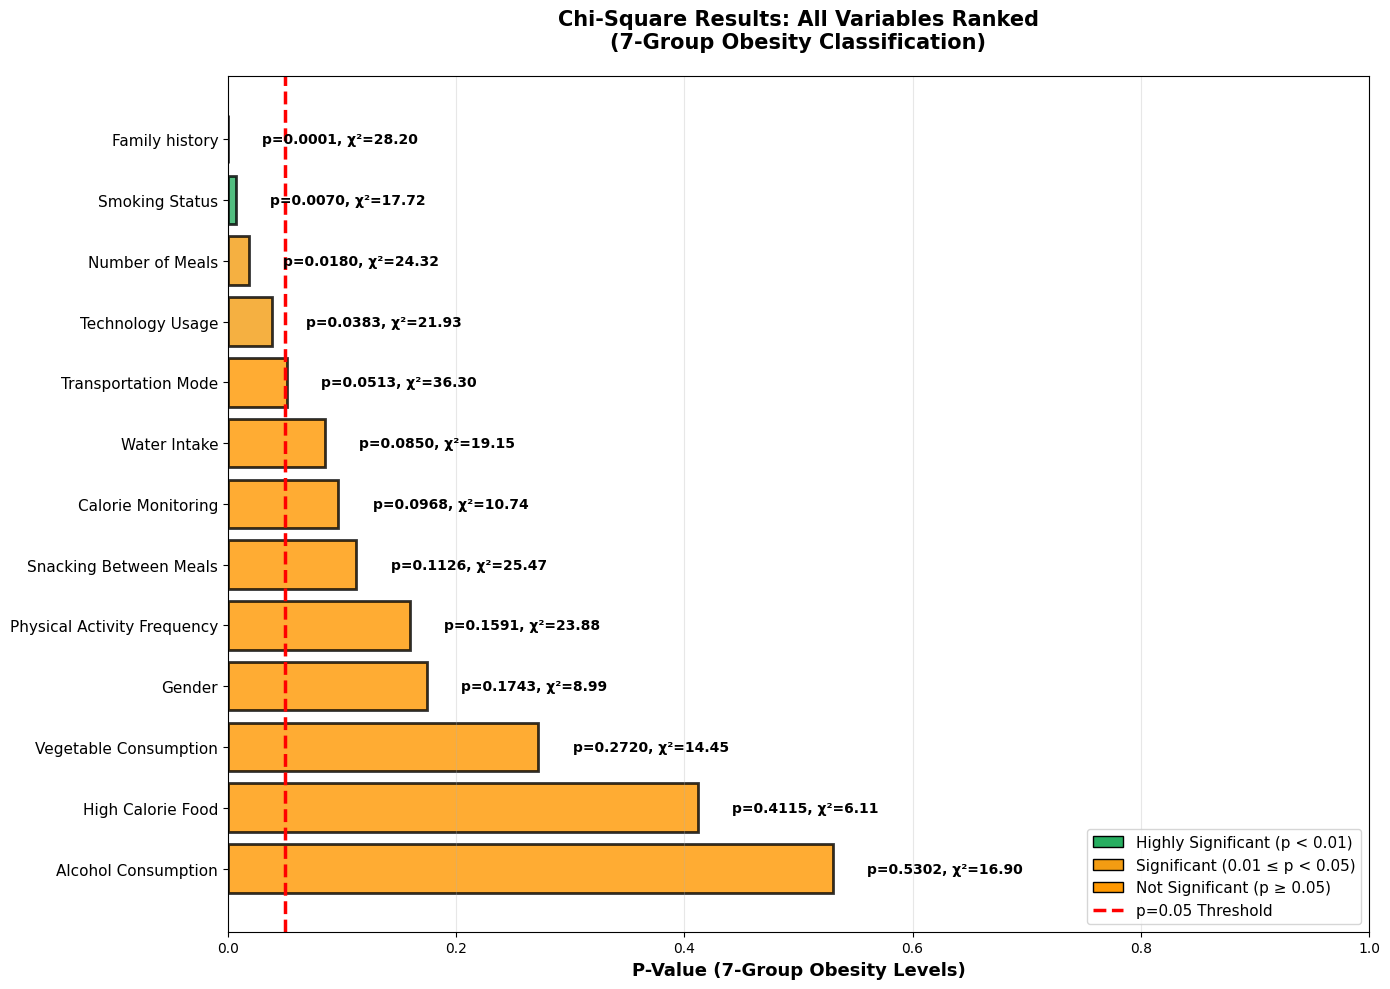


 Data Summary:
                       Variable  Chi2_group  P_value_group
0                Family history       28.20         0.0001
1                Smoking Status       17.72         0.0070
9               Number of Meals       24.32         0.0180
8              Technology Usage       21.93         0.0383
7           Transportation Mode       36.30         0.0513
10                 Water Intake       19.15         0.0850
2            Calorie Monitoring       10.74         0.0968
5        Snacking Between Meals       25.47         0.1126
11  Physical Activity Frequency       23.88         0.1591
4                        Gender        8.99         0.1743
12        Vegetable Consumption       14.45         0.2720
3             High Calorie Food        6.11         0.4115
6           Alcohol Consumption       16.90         0.5302


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create dataframe with actual 7-group obesity results
data = {
    'Variable': [
        'Family history',
        'Smoking Status',
        'Calorie Monitoring',
        'High Calorie Food',
        'Gender',
        'Snacking Between Meals',
        'Alcohol Consumption',
        'Transportation Mode',
        'Technology Usage',
        'Number of Meals',
        'Water Intake',
        'Physical Activity Frequency',
        'Vegetable Consumption'
    ],

    'Chi2_group': [
        28.20,
        17.72,
        10.74,
        6.11,
        8.99,
        25.47,
        16.90,
        36.30,
        21.93,
        24.32,
        19.15,
        23.88,
        14.45
    ],

    'P_value_group': [
        0.0001,
        0.0070,
        0.0968,
        0.4115,
        0.1743,
        0.1126,
        0.5302,
        0.0513,
        0.0383,
        0.0180,
        0.0850,
        0.1591,
        0.2720
    ]
}

df_results = pd.DataFrame(data)

# ===== VISUALIZATION CODE =====
fig, ax = plt.subplots(figsize=(14, 10))

# Sort by p-value
df_sorted = df_results.sort_values('P_value_group')

# Color code based on significance
colors = ['#27AE60' if p < 0.01 else '#F39C12' if p < 0.05 else '#FF9800'
          for p in df_sorted['P_value_group']]

y_pos = np.arange(len(df_sorted))

# Create horizontal bars
bars = ax.barh(y_pos, df_sorted['P_value_group'], color=colors,
                edgecolor='black', linewidth=2, alpha=0.8)

# Add labels with p-value and chi-square
for i, (p_val, chi2) in enumerate(zip(df_sorted['P_value_group'], df_sorted['Chi2_group'])):
    label = f'p={p_val:.4f}, χ²={chi2:.2f}'
    ax.text(p_val + 0.03, i, label, va='center', fontsize=10, fontweight='bold')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted['Variable'], fontsize=11)
ax.set_xlabel('P-Value (7-Group Obesity Levels)', fontsize=13, fontweight='bold')
ax.set_title('Chi-Square Results: All Variables Ranked\n(7-Group Obesity Classification)',
             fontsize=15, fontweight='bold', pad=20)

# Add significance threshold line
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=2.5, label='p=0.05 Threshold')

# Add legend with color meanings
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27AE60', edgecolor='black', label='Highly Significant (p < 0.01)'),
    Patch(facecolor='#F39C12', edgecolor='black', label='Significant (0.01 ≤ p < 0.05)'),
    Patch(facecolor='#FF9800', edgecolor='black', label='Not Significant (p ≥ 0.05)'),
    plt.Line2D([0], [0], color='red', linewidth=2.5, linestyle='--', label='p=0.05 Threshold')
]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')

ax.set_xlim(0, 1.0)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Data Summary:")
print(df_sorted[['Variable', 'Chi2_group', 'P_value_group']])

# Logistic Regression

In [88]:
not_obese = ['Insufficient_Weight', 'Normal_Weight']
df['obese_group'] = df['NObeyesdad'].apply(lambda x: 0 if x in not_obese else 1)

In [89]:
# Binary Encoding
df_encoded = df.copy()
df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 1, 'Female': 0})
df_encoded['family_history_with_overweight'] = df_encoded['family_history_with_overweight'].map({'yes': 1, 'no': 0})
df_encoded['FAVC'] = df_encoded['FAVC'].map({'yes': 1, 'no': 0})
df_encoded['SMOKE'] = df_encoded['SMOKE'].map({'yes': 1, 'no': 0})
df_encoded['SCC'] = df_encoded['SCC'].map({'yes': 1, 'no': 0})

# Mapping for ordered categorical variables
df_encoded['CALC']= df_encoded['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
df_encoded['CAEC'] = df_encoded['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})

# Convert to integer type
df_encoded['FCVC'] = df_encoded['FCVC'].astype(int)
df_encoded['NCP'] = df_encoded['NCP'].astype(int)
df_encoded['CH2O'] = df_encoded['CH2O'].astype(int)
df_encoded['FAF'] = df_encoded['FAF'].astype(int)
df_encoded['TUE'] = df_encoded['TUE'].astype(int)


df_encoded = pd.get_dummies(df_encoded, columns=['MTRANS'], drop_first=True)  # drop_first to avoid dummy trap
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes('bool').columns})
df_encoded

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,TUE,CALC,NObeyesdad,BMI,rank,obese_group,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2,3,1,0,...,1,0,Normal_Weight,24.386526,290.0,0,0,0,1,0
1,0,21.0,1.52,56.0,1,0,3,3,1,1,...,0,1,Normal_Weight,24.238227,277.0,0,0,0,1,0
2,1,23.0,1.80,77.0,1,0,2,3,1,0,...,1,2,Normal_Weight,23.765432,254.0,0,0,0,1,0
3,1,27.0,1.80,87.0,0,0,3,3,1,0,...,0,2,Overweight_Level_I,26.851852,376.5,1,0,0,0,1
4,1,22.0,1.78,89.8,0,0,2,1,1,0,...,0,1,Overweight_Level_II,28.342381,410.0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,1,20.0,1.80,65.0,0,1,2,3,2,0,...,0,1,Normal_Weight,20.061728,89.0,0,0,1,0,0
494,0,18.0,1.67,66.0,0,1,3,3,1,0,...,0,1,Normal_Weight,23.665244,249.0,0,0,0,1,0
495,1,19.0,1.80,60.0,1,1,3,1,3,0,...,0,0,Normal_Weight,18.518519,39.0,0,0,1,0,0
496,1,18.0,1.72,53.0,1,1,2,3,1,0,...,2,1,Insufficient_Weight,17.915089,23.5,0,0,0,1,0


In [90]:
#Binary Logistic Regression
X = df_encoded[['family_history_with_overweight','NCP','SMOKE','CH2O','FAF','TUE','CALC','Age','CAEC','SCC','FCVC','Gender','MTRANS_Bike','MTRANS_Motorbike','MTRANS_Public_Transportation','MTRANS_Walking']]
y = df_encoded['obese_group']
X = sm.add_constant(X) # Add a constant for the intercept
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.546499
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            obese_group   No. Observations:                  498
Model:                          Logit   Df Residuals:                      481
Method:                           MLE   Df Model:                           16
Date:                Thu, 06 Nov 2025   Pseudo R-squ.:                  0.1602
Time:                        13:17:19   Log-Likelihood:                -272.16
converged:                       True   LL-Null:                       -324.07
Covariance Type:            nonrobust   LLR p-value:                 6.625e-15
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -1.9770      0.893     -2.213     

In [91]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Compute VIF to check multicollinearity
X_vif = X.copy()
X_vif = sm.add_constant(X_vif)  # add intercept term

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print(vif_data)

                          Variable        VIF
0                            const  68.277508
1   family_history_with_overweight   1.070165
2                              NCP   1.102368
3                            SMOKE   1.058838
4                             CH2O   1.133617
5                              FAF   1.162968
6                              TUE   1.129430
7                             CALC   1.082865
8                              Age   1.357343
9                             CAEC   1.067367
10                             SCC   1.093144
11                            FCVC   1.095195
12                          Gender   1.138389
13                     MTRANS_Bike   1.093526
14                MTRANS_Motorbike   1.123705
15    MTRANS_Public_Transportation   1.865991
16                  MTRANS_Walking   1.593949


In [92]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

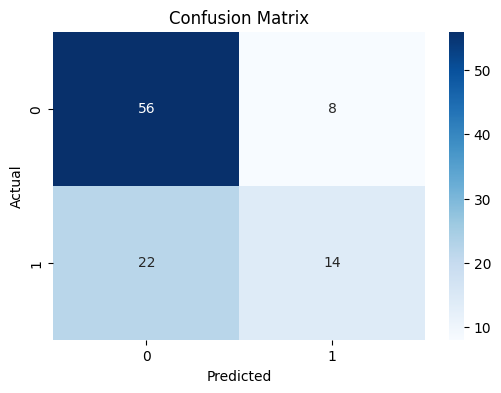


Classification Report:
              precision    recall  f1-score   support

           0      0.718     0.875     0.789        64
           1      0.636     0.389     0.483        36

    accuracy                          0.700       100
   macro avg      0.677     0.632     0.636       100
weighted avg      0.689     0.700     0.679       100



In [93]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the LR model
classifier = LogisticRegression(max_iter=1000, solver='lbfgs')
classifier.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = classifier.predict(X_test_scaled)

# Evaluate
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

In [94]:
#Binary Logistic Regression
X = df_encoded[['family_history_with_overweight','NCP','CH2O','FAF','Age','Gender']]
y = df_encoded['obese_group']
X = sm.add_constant(X) # Add a constant for the intercept
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.556146
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            obese_group   No. Observations:                  498
Model:                          Logit   Df Residuals:                      491
Method:                           MLE   Df Model:                            6
Date:                Thu, 06 Nov 2025   Pseudo R-squ.:                  0.1454
Time:                        13:17:20   Log-Likelihood:                -276.96
converged:                       True   LL-Null:                       -324.07
Covariance Type:            nonrobust   LLR p-value:                 4.030e-18
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -3.4468      0.618     -5.580     

In [95]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Compute VIF to check multicollinearity
X_vif = X.copy()
X_vif = sm.add_constant(X_vif)  # add intercept term

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print(vif_data)

                         Variable        VIF
0                           const  30.316113
1  family_history_with_overweight   1.037678
2                             NCP   1.041723
3                            CH2O   1.100078
4                             FAF   1.093100
5                             Age   1.018831
6                          Gender   1.059248


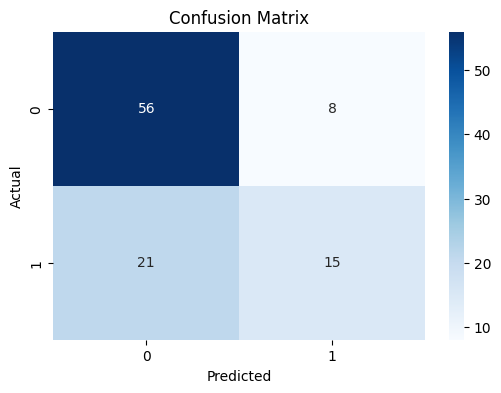


Classification Report:
              precision    recall  f1-score   support

           0      0.727     0.875     0.794        64
           1      0.652     0.417     0.508        36

    accuracy                          0.710       100
   macro avg      0.690     0.646     0.651       100
weighted avg      0.700     0.710     0.691       100



In [96]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the LR model
classifier = LogisticRegression(max_iter=1000, solver='lbfgs')
classifier.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = classifier.predict(X_test_scaled)

# Evaluate
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))